# Balloon autonomy: results

This notebook only shows results. Every number comes from the files the experiment scripts write under `results`; the code that produced them is in `src/stratoballoon/` and `experiments/`. Labels: **REAL DATA** (ERA5, radiosondes), **MODEL PREDICTION** (forecasts scored against ERA5), **SIMULATION** (a simplified research model of the balloon, not flight performance).

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
R = Path('..') / 'results'
pd.set_option('display.width', 160)
def show(sub, png, csv=None):
    p = R / sub / png
    if p.exists():
        display(Image(str(p)))
    else:
        print('not generated yet:', p)
    if csv and (R / sub / csv).exists():
        display(pd.read_csv(R / sub / csv).round(3))

## How good is the truth?

ERA5 against radiosondes at eight Indian stations (**REAL DATA**).

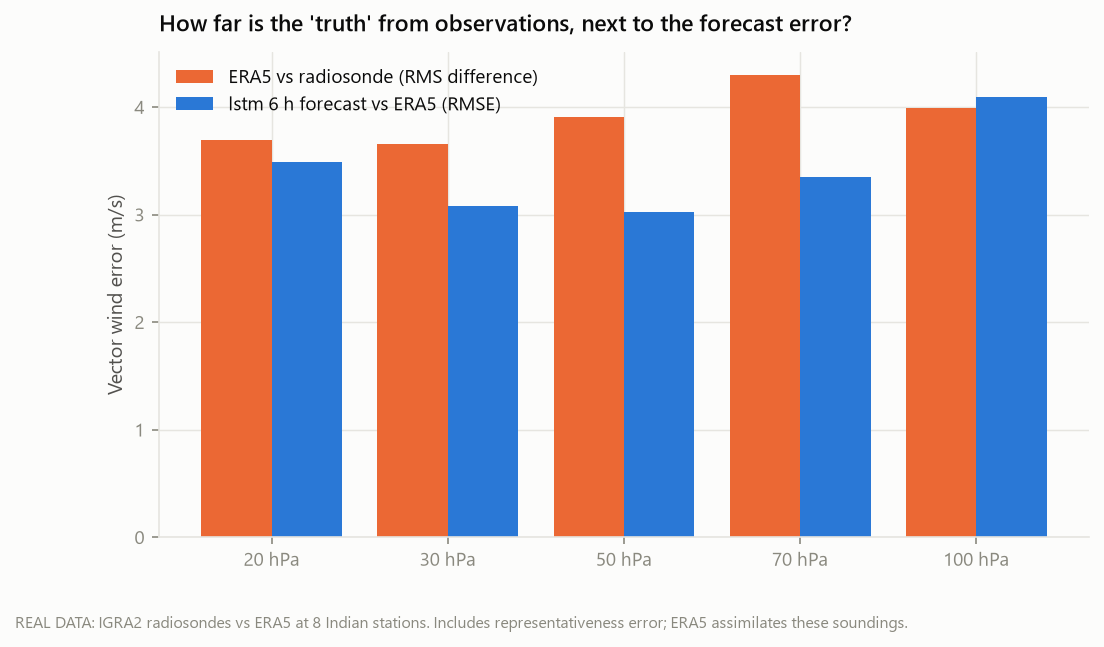

,level_hpa,n,vector_rms_diff_ms,bias_u_ms,bias_v_ms,obs_mean_speed_ms,forecast_6h_vector_rmse_ms
0,20,13787.0,3.694,0.245,0.048,13.697,3.491
1,30,15408.0,3.658,0.122,-0.016,12.055,3.084
2,50,17558.0,3.909,-0.067,-0.106,10.999,3.026
3,70,19131.0,4.296,-0.094,-0.177,13.542,3.351
4,100,21256.0,3.996,-0.204,-0.267,20.150,4.093


In [2]:
show('radiosondes', 'era5_vs_radiosondes.png', 'summary.csv')

## Are the forecast's uncertainty regions honest?

Conformal regions calibrated on the previous year, checked on the test year (**MODEL PREDICTION**).

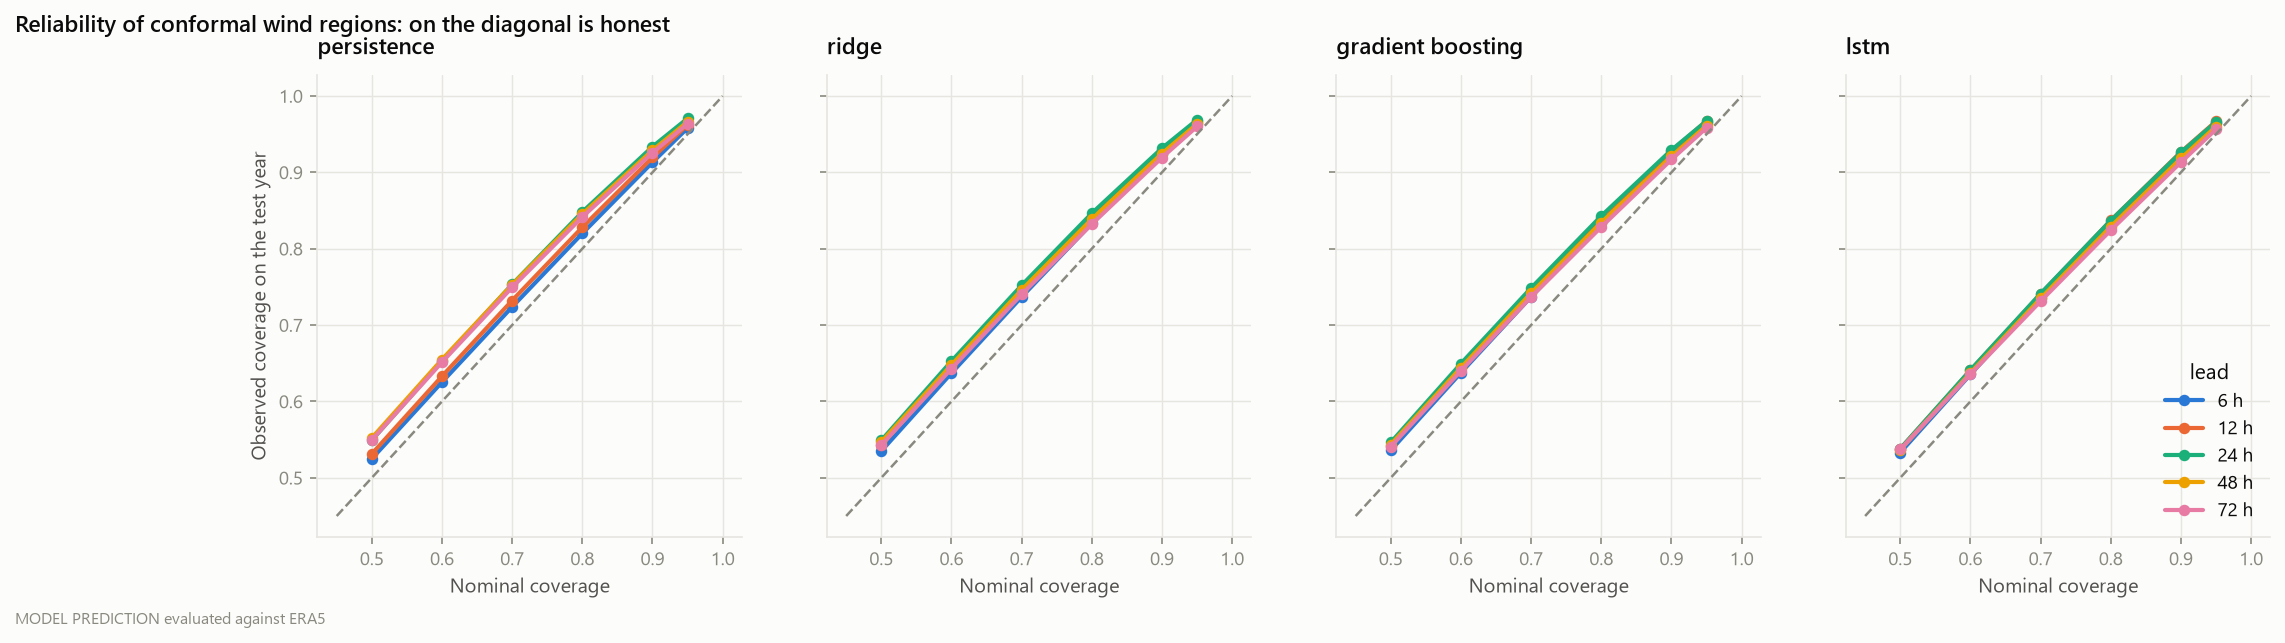

In [3]:
show('uncertainty', 'reliability.png')

## Where will a drifting balloon be?

Predicted against actual positions (**MODEL PREDICTION**).

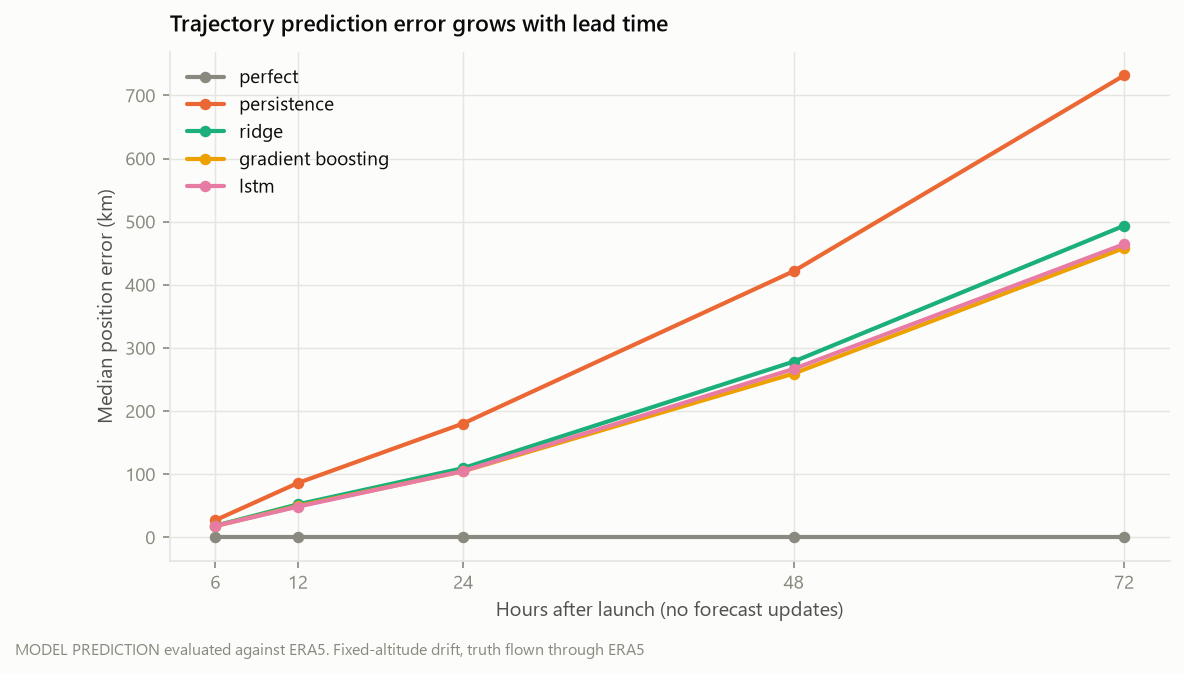

,source,lead_h,n_scored,median_km,mean_km,p90_km
0,perfect,6,600,0.000,0.000,0.000
1,perfect,12,600,0.000,0.000,0.000
2,perfect,24,600,0.000,0.000,0.000
3,perfect,48,510,0.000,0.000,0.000
4,perfect,72,391,0.000,0.000,0.000
5,persistence,6,600,27.149,30.259,52.750
6,persistence,12,600,86.181,91.312,156.379
7,persistence,24,600,180.328,198.715,345.374
8,persistence,48,499,421.589,463.009,817.877
9,persistence,72,369,731.669,843.511,1591.015


In [4]:
show('trajectory', 'position_error.png', 'position_error.csv')

One launch, with the ensemble cone and the wind it flew through.

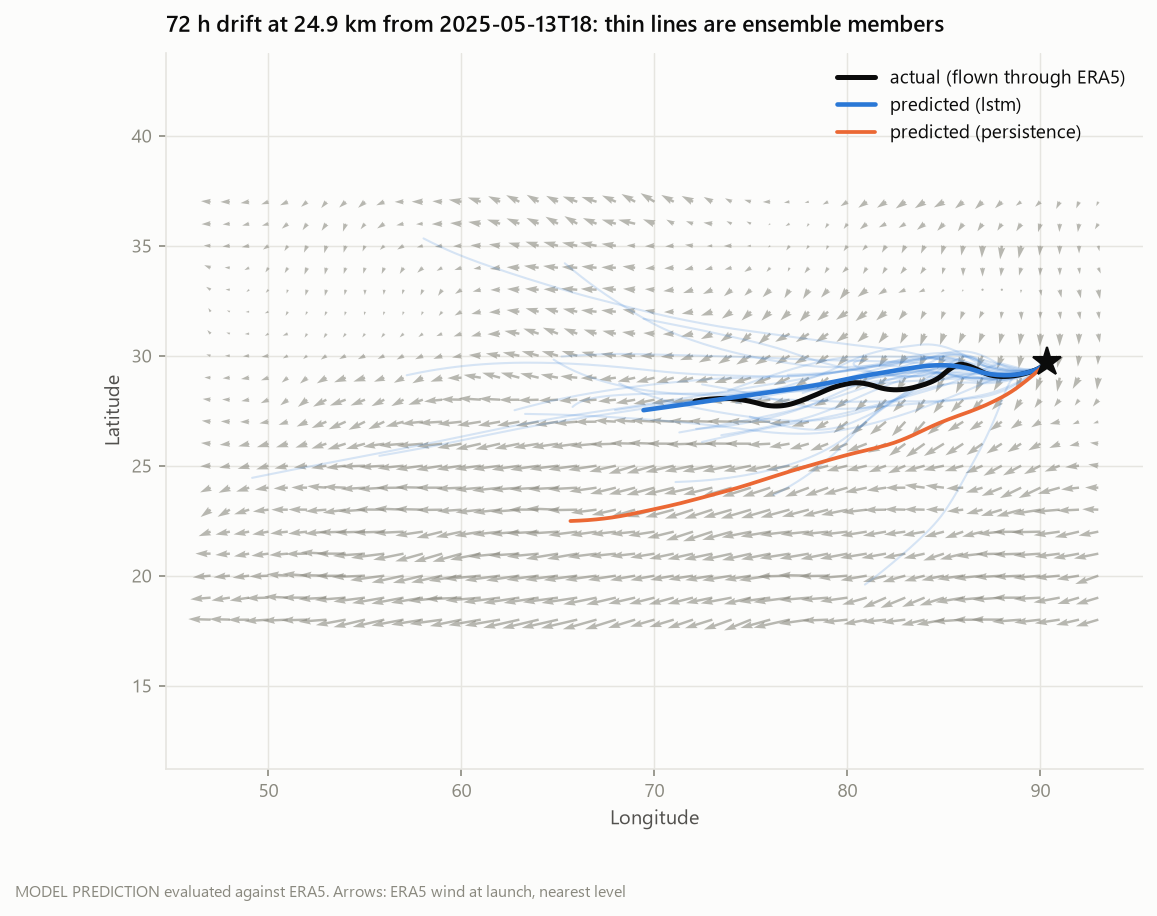

In [5]:
show('trajectory', 'example_cone.png')

## Which controller keeps the balloon on station?

Identical missions for every controller (**SIMULATION**).

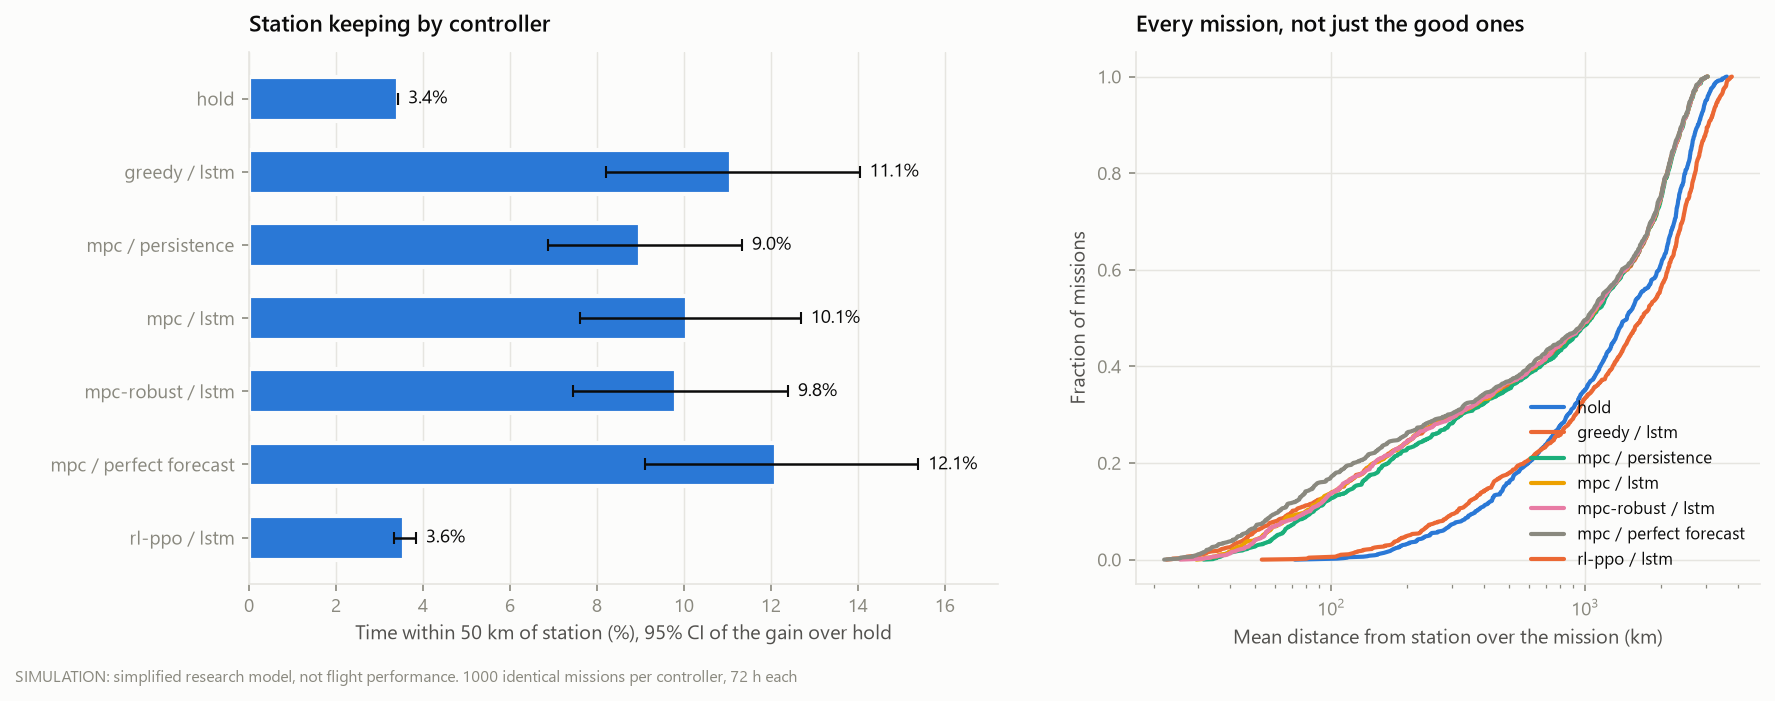

,run,twr50,mean_dist_km,median_dist_km,pump_energy_wh,target_changes,left_domain,battery_empty,twr50_vs_hold,twr50_vs_hold_lo,twr50_vs_hold_hi,dist_vs_hold,dist_vs_hold_lo,dist_vs_hold_hi,twr50_vs_mpc_best,twr50_vs_mpc_best_lo,twr50_vs_mpc_best_hi,dist_vs_mpc_best,dist_vs_mpc_best_lo,dist_vs_mpc_best_hi
0,hold,0.034,1555.681,1462.102,17.076,0.000,0.362,0.0,0.000,0.000,0.000,0.000,0.000,0.000,-0.066,-0.093,-0.042,414.198,374.334,455.313
1,greedy / lstm,0.111,1145.341,1038.453,449.111,3.187,0.223,0.0,0.077,0.048,0.106,-410.340,-451.620,-370.274,0.010,0.005,0.015,3.858,1.582,6.408
2,mpc / persistence,0.090,1158.308,1062.193,527.093,4.099,0.227,0.0,0.056,0.035,0.079,-397.373,-439.242,-357.179,-0.011,-0.016,-0.006,16.825,13.579,20.238
3,mpc / lstm,0.101,1141.483,1044.703,379.994,3.100,0.221,0.0,0.066,0.042,0.093,-414.198,-455.313,-374.334,0.000,0.000,0.000,0.000,0.000,0.000
4,mpc-robust / lstm,0.098,1141.150,1037.843,406.534,3.562,0.220,0.0,0.064,0.040,0.090,-414.531,-455.849,-374.655,-0.003,-0.006,0.001,-0.333,-1.373,0.829
5,mpc / perfect forecast,0.121,1123.748,1025.051,326.529,2.727,0.213,0.0,0.087,0.057,0.120,-431.933,-473.085,-392.205,0.020,0.012,0.030,-17.735,-21.869,-14.096
6,rl-ppo / lstm,0.036,1690.959,1668.228,16.380,0.250,0.435,0.0,0.001,-0.001,0.004,135.278,101.541,169.021,-0.065,-0.090,-0.041,549.476,496.142,605.230


In [6]:
show('control', 'controller_comparison.png', 'summary.csv')

One mission in detail: track, altitude commands, battery.

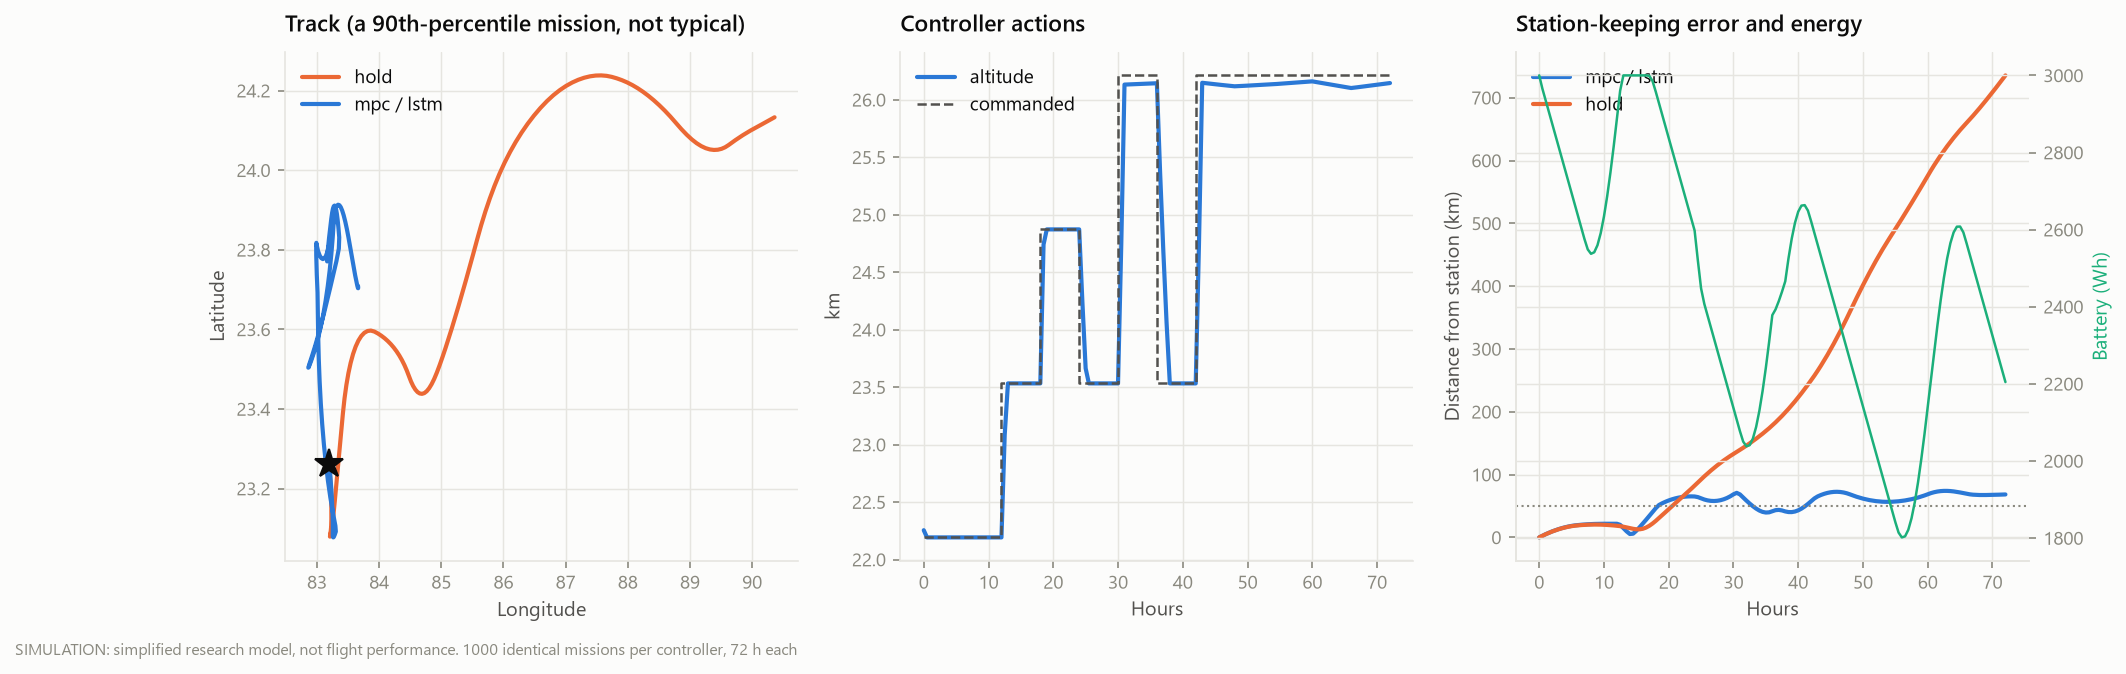

In [7]:
show('control', 'example_mission.png')

## When is station keeping possible at all?

With a perfect forecast, the upper bound (**SIMULATION**).

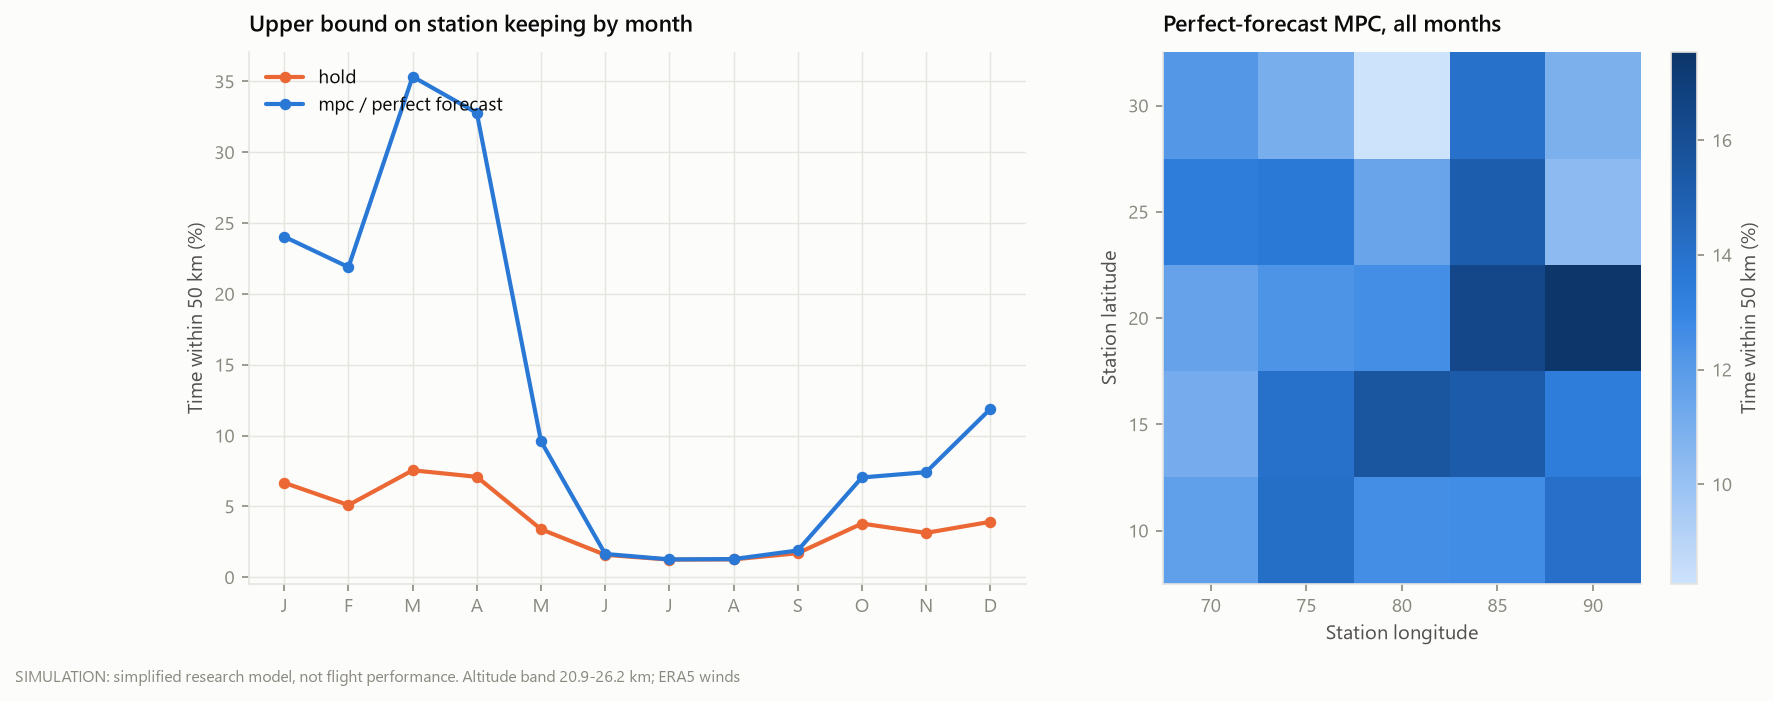

,month,hold,mpc / perfect forecast
0,1,0.067,0.240
1,2,0.051,0.219
2,3,0.076,0.353
3,4,0.071,0.328
4,5,0.034,0.096
5,6,0.016,0.017
6,7,0.013,0.013
7,8,0.013,0.013
8,9,0.017,0.019
9,10,0.038,0.070


In [8]:
show('feasibility', 'feasibility.png', 'twr50_by_month.csv')

## What breaks it?

Injected faults (**SIMULATION**).

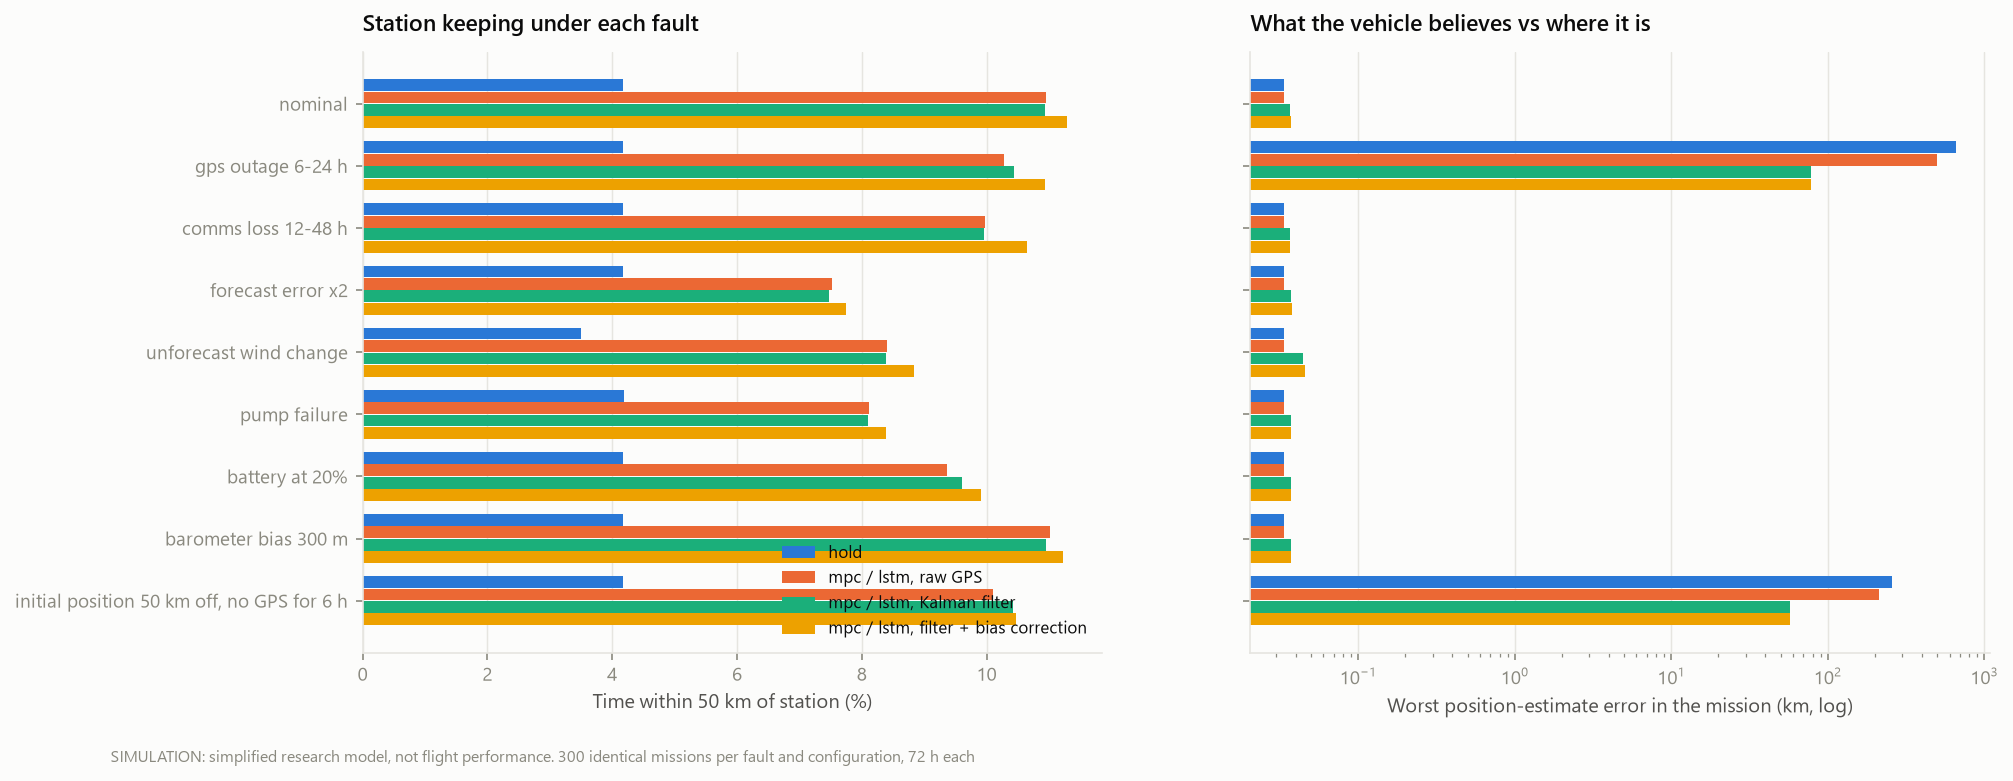

,fault,config,twr50,mean_dist_km,pump_energy_wh,battery_empty,est_err_mean_km,est_err_max_km,max_forecast_age_h,max_backlog_min
0,nominal,hold,0.042,1551.255,16.697,0.0,0.013,0.034,3.00,0.000
1,nominal,"mpc / lstm, raw GPS",0.110,1124.346,396.929,0.0,0.013,0.034,3.00,0.000
2,nominal,"mpc / lstm, Kalman filter",0.109,1124.375,396.542,0.0,0.013,0.037,3.00,0.000
3,nominal,"mpc / lstm, filter + bias correction",0.113,1124.209,437.302,0.0,0.013,0.037,3.00,0.000
4,gps outage 6-24 h,hold,0.042,1551.255,16.697,0.0,84.226,664.476,3.00,0.000
5,gps outage 6-24 h,"mpc / lstm, raw GPS",0.103,1126.824,392.287,0.0,63.026,499.740,3.00,0.000
6,gps outage 6-24 h,"mpc / lstm, Kalman filter",0.104,1124.942,392.570,0.0,8.152,78.304,3.00,0.000
7,gps outage 6-24 h,"mpc / lstm, filter + bias correction",0.109,1124.611,432.397,0.0,8.088,78.351,3.00,0.000
8,comms loss 12-48 h,hold,0.042,1551.255,16.697,0.0,0.013,0.034,31.43,1789.693
9,comms loss 12-48 h,"mpc / lstm, raw GPS",0.100,1136.488,355.497,0.0,0.013,0.034,31.43,1789.693


In [9]:
show('robustness', 'robustness.png', 'summary.csv')

## Planning a mission from Vijayawada

(**SIMULATION** over forecast scenarios).

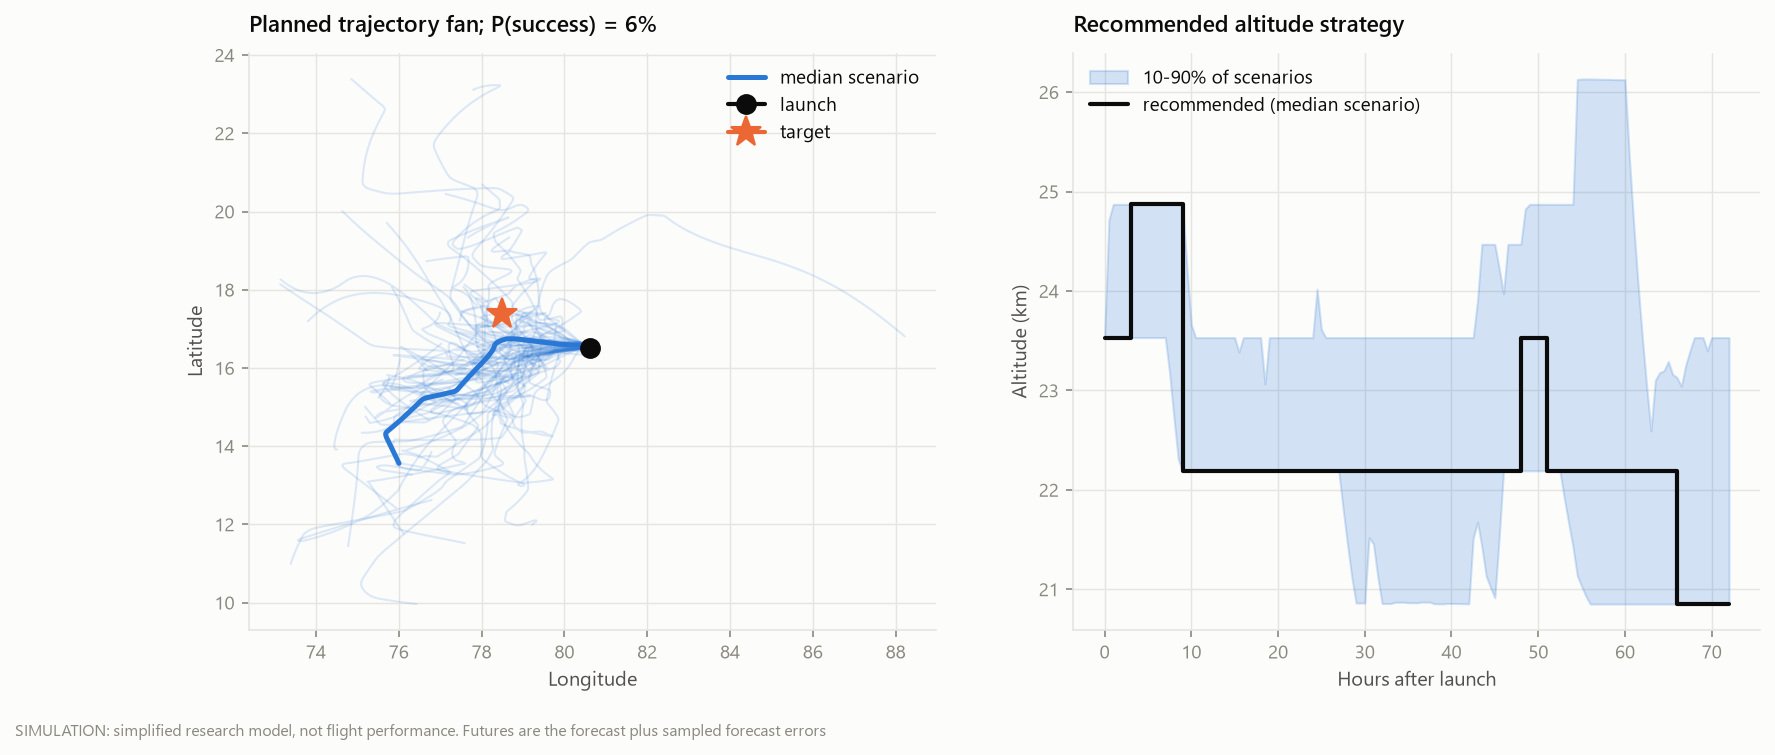

In [10]:
show('planner', 'plan.png')